In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot
%matplotlib inline

In [2]:
df = pd.read_csv("binance_btc_4h_2018_2026_features.csv")

In [3]:
df.head()

,Timestamp,Open,High,Low,Close,Volume,volume_adi,volume_obv,volume_cmf,volume_fi,...,momentum_ppo,momentum_ppo_signal,momentum_ppo_hist,momentum_pvo,momentum_pvo_signal,momentum_pvo_hist,momentum_kama,others_dr,others_dlr,others_cr
0,2018-01-01 00:00:00,13715.65,13715.65,13155.38,13410.03,1676.204807,-152.491047,1676.204807,-0.090974,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,13410.030000,0.000000,0.000000,0.000000
1,2018-01-01 04:00:00,13434.98,13818.55,13322.15,13570.35,1302.214836,-152.491047,2978.419643,-0.051199,208771.082508,...,0.095285,0.019057,0.076228,-1.809762,-0.361952,-1.447809,13473.327797,1.195523,1.188433,1.195523
2,2018-01-01 08:00:00,13569.98,13735.24,13001.13,13220.56,1319.755931,-683.280627,1658.663712,-0.158970,112998.438277,...,-0.039086,0.007428,-0.046514,-3.168972,-0.923356,-2.245615,13371.544768,-2.577605,-2.611407,-1.412898
3,2018-01-01 12:00:00,13220.56,13330.00,12750.00,13247.00,1831.933153,624.340623,3490.596865,0.101848,103775.277461,...,-0.128381,-0.019734,-0.108648,-1.645296,-1.067744,-0.577551,13321.621062,0.199992,0.199792,-1.215732
4,2018-01-01 16:00:00,13247.00,13290.65,12940.00,13240.37,1092.337234,1403.415538,2398.259631,0.194313,87915.638415,...,-0.200973,-0.055981,-0.144991,-4.157383,-1.685672,-2.471711,13288.951318,-0.050049,-0.050062,-1.265172


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17946 entries, 0 to 17945
Data columns (total 92 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Timestamp                  17946 non-null  object 
 1   Open                       17946 non-null  float64
 2   High                       17946 non-null  float64
 3   Low                        17946 non-null  float64
 4   Close                      17946 non-null  float64
 5   Volume                     17946 non-null  float64
 6   volume_adi                 17946 non-null  float64
 7   volume_obv                 17946 non-null  float64
 8   volume_cmf                 17946 non-null  float64
 9   volume_fi                  17946 non-null  float64
 10  volume_em                  17946 non-null  float64
 11  volume_sma_em              17946 non-null  float64
 12  volume_vpt                 17946 non-null  float64
 13  volume_vwap                17946 non-null  flo

In [5]:
df.describe()

,Open,High,Low,Close,Volume,volume_adi,volume_obv,volume_cmf,volume_fi,volume_em,...,momentum_ppo,momentum_ppo_signal,momentum_ppo_hist,momentum_pvo,momentum_pvo_signal,momentum_pvo_hist,momentum_kama,others_dr,others_dlr,others_cr
count,17946.000000,17946.000000,17946.000000,17946.000000,17946.000000,1.794600e+04,1.794600e+04,17946.000000,1.794600e+04,1.794600e+04,...,17946.000000,17946.000000,17946.000000,17946.000000,17946.000000,17946.000000,17946.000000,17946.000000,17946.000000,17946.000000
mean,38246.054084,38560.447053,37910.445938,38249.396376,10713.225323,5.403734e+06,1.523420e+06,0.042846,-8.769303e+04,2.068610e+06,...,0.042634,0.042458,0.000176,-1.371968,-1.371957,-0.000011,38251.598862,0.019184,0.009467,185.229760
std,32485.244129,32688.635174,32268.905198,32485.782235,14368.862866,3.702966e+06,1.405837e+06,0.127283,3.669183e+06,1.292617e+10,...,1.593816,1.507863,0.461715,12.487537,9.882487,6.827888,32483.276584,1.392070,1.395364,242.249885
min,3172.620000,3210.000000,3156.260000,3172.050000,5.887034,-7.245532e+03,-9.172363e+05,-0.407458,-6.251811e+07,-6.654058e+11,...,-11.814582,-10.322847,-3.988297,-50.715853,-45.670440,-17.731704,3246.287732,-20.496236,-22.936582,-76.345691
25%,9548.630000,9630.747500,9459.947500,9548.502500,3659.548032,1.248562e+06,-3.672053e+03,-0.044884,-5.306896e+05,-4.632543e+08,...,-0.688091,-0.651313,-0.228206,-9.236627,-7.646063,-4.599729,9600.709429,-0.470950,-0.472062,-28.795816
50%,28127.635000,28374.145000,27908.885000,28134.410000,6257.523531,5.535495e+06,1.712035e+06,0.041658,-6.589064e+03,5.126519e+06,...,0.046090,0.047809,-0.005452,-1.800241,-1.549046,-0.686334,28131.222590,0.019369,0.019367,109.801246
75%,59414.880000,59932.282500,58866.500000,59416.972500,11361.605046,9.260156e+06,3.058933e+06,0.126877,4.952246e+05,6.559702e+08,...,0.854289,0.827565,0.222171,6.007576,4.751636,3.805859,59273.239605,0.513637,0.512322,343.078595
max,125410.800000,126199.630000,124800.000000,125410.810000,284711.694213,1.011630e+07,3.422245e+06,0.521882,7.245077e+07,1.756758e+11,...,6.341956,5.502219,3.008708,59.658646,36.224820,44.601687,123121.777258,14.749019,13.757711,835.201562


In [6]:
# Open, High, Low, Close, Volume
# volatility_bbm, volatility_bbh, volatility_bbl, volatility_kcc, volatility_kch, volatility_kcl, volatility_dcl, 
# volatility_dch, volatility_dcm, trend_sma_fast, trend_sma_slow, trend_ema_fast, 
# trend_ema_slow, trend_ichimoku_conv, trend_ichimoku_base, trend_ichimoku_a, trend_ichimoku_b, 
# trend_visual_ichimoku_a, trend_visual_ichimoku_b, trend_psar_up, trend_psar_down, momentum_kama, volume_vwap
# volume_adi, volume_obv, volume_fi, volume_nvi
# volatility_atr

# pct_change uygulanacak kolon isimleri

In [7]:
# momentum_rsi, momentum_stoch, momentum_stoch_signal, momentum_stoch_rsi, momentum_stoch_rsi_k,
# momentum_stoch_rsi_d, momentum_uo, trend_adx, trend_adx_pos, trend_adx_neg, trend_aroon_up
# trend_aroon_down, trend_aroon_ind, trend_stc, volume_mfi

In [8]:
# trend_macd, trend_macd_signal, trend_macd_diff, trend_cci, trend_vortex_ind_pos, 
# trend_vortex_ind_neg, trend_vortex_ind_diff, trend_trix, trend_kst, trend_kst_sig,
# trend_kst_diff, momentum_tsi, momentum_wr, momentum_ao, momentum_ppo, momentum_ppo_signal,
# momentum_ppo_hist, momentum_pvo, momentum_pvo_signal, momentum_pvo_hist, 
# trend_dpo, trend_mass_index, volume_cmf, volume_em, volume_sma_em, volume_vpt
# volatility_bbw, volatility_bbp, volatility_kcw, volatility_kcp, 
# volatility_dcw, volatility_dcp, volatility_ui, momentum_roc

# diff uygulanacak kolon isimleri

In [9]:
# istatiksel filtreleme (korelasyon matrisi) -> tahmin edilmesi istenen değer ile diğer değişkenlerin bağlantısı 
# en yüksek olanları seçer diğerlerini drop ederiz.

# algoritmik puanlama (Tree-based feature importance) -> korelasyon her zaman tahmin edilmesi istenen değer 
# ile diğer değişkenlerin bağlantısını doğru bulamayabilir.
# ham veri setini LightGBM veya Random Forest içerisine veririz.

# 1.ilk sırada EDA yapılarak modele vermeden önce elimizde ne olduğuna bakılmalı

# 2. Data cleaning & preprocessing yapılmalı  ( preprocessing değerler arasındaki devasa farkları sayıları küçülterek
# önem sırasına koymaya yarar.

# 3. Feature Engineering yapılmalı 

# 4. Feature Selection yapılmalı ( birbirinin kopyası olan satırlardan birisi silinir, hedef değişkenle 
# en alakalı satırlar bırakılır. korelasyonu 0.9 veya -0.9 üzeri olanlardan silinecekler arasında
# hedef değişkenle en alakalı olan bırakılır diğer satır silinir.)

# Train test split

# Model Training & Hyperparameter Tuning 

# Backtesting & Evaluation(modelin hiç görmediği test verisiyle sonuclara bakılır)

#veriyi kronolojik olarak nasıl böleceğim? bu soruyu cevapladıktan sonra 
#Hedef değişkenin (Target/y) tam olarak ne olacak? Yarının kapanış fiyatını tahmin etmeye mi çalışıyorsun (Regresyon), yoksa bir sonraki mumun yeşil mi kırmızı mı olacağını mı (Sınıflandırma)?
#işin sonunda da 

<Axes: >

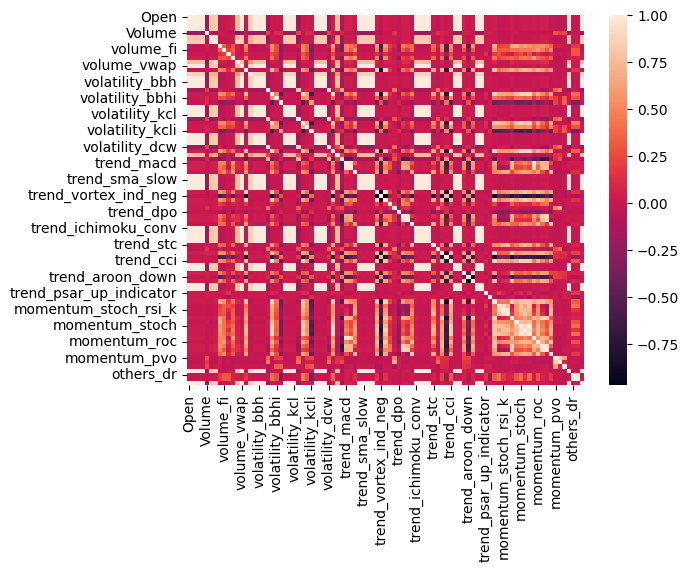

In [11]:
sns.heatmap(df.corr(numeric_only=True))

In [12]:
df["Close_Future"] = df["Close"].shift(-1)

In [13]:
corr_matrix = df.corr(numeric_only=True)

In [14]:
future_matrix = corr_matrix[(corr_matrix > 0.3) & (corr_matrix <0.5)]

In [15]:
future_matrix

,Open,High,Low,Close,Volume,volume_adi,volume_obv,volume_cmf,volume_fi,volume_em,...,momentum_ppo_signal,momentum_ppo_hist,momentum_pvo,momentum_pvo_signal,momentum_pvo_hist,momentum_kama,others_dr,others_dlr,others_cr,Close_Future
Open,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
High,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Low,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Close,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Volume,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
momentum_kama,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
others_dr,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.308212,0.303524,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
others_dlr,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.309850,0.303544,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
others_cr,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
df[df["Volume"] == 0]

,Timestamp,Open,High,Low,Close,Volume,volume_adi,volume_obv,volume_cmf,volume_fi,...,momentum_ppo_signal,momentum_ppo_hist,momentum_pvo,momentum_pvo_signal,momentum_pvo_hist,momentum_kama,others_dr,others_dlr,others_cr,Close_Future


In [17]:
pct_change_columns = [
    "Open", "High", "Low", "Close", "Volume",
    "volatility_bbm", "volatility_bbh", "volatility_bbl",
    "volatility_kcc", "volatility_kch", "volatility_kcl",
    "volatility_dcl", "volatility_dch", "volatility_dcm",
    "trend_sma_fast", "trend_sma_slow", "trend_ema_fast", "trend_ema_slow",
    "trend_ichimoku_conv", "trend_ichimoku_base", "trend_ichimoku_a", "trend_ichimoku_b",
    "trend_visual_ichimoku_a", "trend_visual_ichimoku_b", 
    "trend_psar_up", "trend_psar_down", 
    "momentum_kama", "volume_vwap",
    "volume_adi", "volume_obv", "volume_fi", "volume_nvi",
    "volatility_atr"]

In [18]:
df[pct_change_columns] = df[pct_change_columns].pct_change()

In [20]:
diff_columns = [
    "momentum_rsi", "momentum_stoch", "momentum_stoch_signal", 
    "momentum_stoch_rsi", "momentum_stoch_rsi_k", "momentum_stoch_rsi_d", 
    "momentum_uo", "trend_adx", "trend_adx_pos", "trend_adx_neg", 
    "trend_aroon_up", "trend_aroon_down", "trend_aroon_ind", "trend_stc", 
    "volume_mfi", "trend_macd", "trend_macd_signal", "trend_macd_diff", 
    "trend_cci", "trend_vortex_ind_pos", "trend_vortex_ind_neg", 
    "trend_vortex_ind_diff", "trend_trix", "trend_kst", "trend_kst_sig", 
    "trend_kst_diff", "momentum_tsi", "momentum_wr", "momentum_ao", 
    "momentum_ppo", "momentum_ppo_signal", "momentum_ppo_hist", 
    "momentum_pvo", "momentum_pvo_signal", "momentum_pvo_hist", 
    "trend_dpo", "trend_mass_index", "volume_cmf", "volume_em", 
    "volume_sma_em", "volume_vpt", "volatility_bbw", "volatility_bbp", 
    "volatility_kcw", "volatility_kcp", "volatility_dcw", "volatility_dcp", 
    "volatility_ui", "momentum_roc"
]

In [21]:
df[diff_columns] = df[diff_columns].diff()

In [22]:
df.tail()

,Timestamp,Open,High,Low,Close,Volume,volume_adi,volume_obv,volume_cmf,volume_fi,...,momentum_ppo_signal,momentum_ppo_hist,momentum_pvo,momentum_pvo_signal,momentum_pvo_hist,momentum_kama,others_dr,others_dlr,others_cr,Close_Future
17941,2026-03-12 20:00:00,0.001385,0.002340,0.003473,0.001548,-0.353967,0.000108,0.000765,-0.012816,-0.090914,...,0.011828,0.004052,-3.770688,-1.059419,-2.711270,0.000495,0.154787,0.154667,426.034170,71405.75
17942,2026-03-13 00:00:00,0.001548,0.017894,0.005325,0.012254,1.463811,0.000150,0.001883,0.004910,0.973352,...,0.030184,0.073423,3.580173,-0.131500,3.711673,0.003103,1.225395,1.217948,432.480166,71612.22
17943,2026-03-13 04:00:00,0.012254,-0.004545,0.011283,0.002892,-0.273478,0.000313,0.001366,0.062169,-0.044699,...,0.043338,0.052616,-0.164659,-0.138132,-0.026527,0.001965,0.289150,0.288733,434.019834,72228.82
17944,2026-03-13 08:00:00,0.002892,0.012602,0.002881,0.008610,0.220850,0.000211,0.001665,0.026273,0.231767,...,0.061682,0.073375,1.578355,0.205165,1.373190,0.002836,0.861026,0.857341,438.617885,73328.73
17945,2026-03-13 12:00:00,0.008610,0.014013,0.011553,0.015228,-0.036825,0.000301,0.001601,-0.006916,0.379690,...,0.092901,0.124879,0.867521,0.337637,0.529884,0.009513,1.522813,1.511335,446.820029,NaN


In [23]:
df.dropna(inplace=True)

<Axes: >

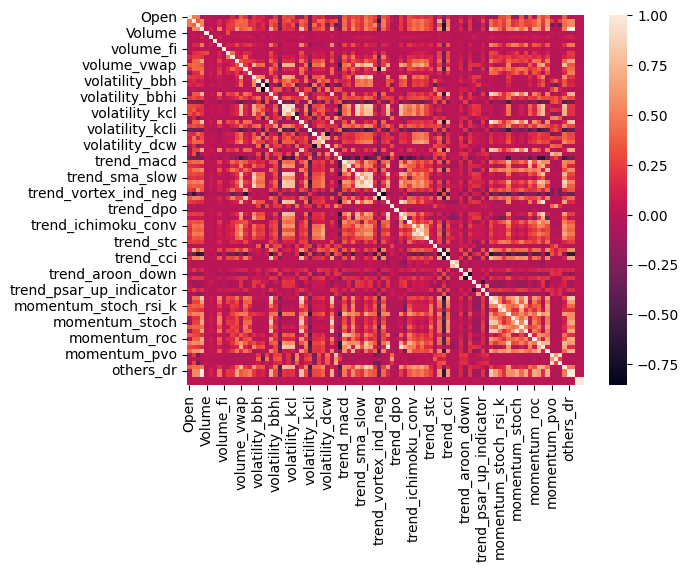

In [25]:
sns.heatmap(df.corr(numeric_only=True))

In [26]:
corr_matrix = df.corr(numeric_only=True).abs()

In [27]:
df

,Timestamp,Open,High,Low,Close,Volume,volume_adi,volume_obv,volume_cmf,volume_fi,...,momentum_ppo_signal,momentum_ppo_hist,momentum_pvo,momentum_pvo_signal,momentum_pvo_hist,momentum_kama,others_dr,others_dlr,others_cr,Close_Future
9,2018-01-02 12:00:00,0.011016,0.020384,0.011116,0.014828,0.296473,0.143830,3.248720,-0.005467,0.739880,...,0.044560,0.146750,4.685514,2.382254,2.303260,0.009162,1.482802,1.471916,2.087989,14732.75
10,2018-01-02 16:00:00,0.014827,0.113613,0.003906,0.076166,0.512316,0.603697,1.156370,0.029129,3.856841,...,0.188102,0.574168,8.417721,3.589347,4.828374,0.017448,7.616638,7.340508,9.863662,14675.11
11,2018-01-02 20:00:00,0.074507,-0.020240,0.077094,-0.003912,-0.277071,-0.630033,-0.387676,-0.090910,-0.175767,...,0.259411,0.285237,1.070497,3.085577,-2.015080,0.010414,-0.391237,-0.392005,9.433834,14818.49
12,2018-01-03 00:00:00,-0.001361,0.009214,0.007976,0.009770,-0.102197,-1.343105,0.568420,-0.056591,-0.053687,...,0.304770,0.181437,-0.647023,2.339057,-2.986080,0.023580,0.977028,0.972286,10.503034,15170.00
13,2018-01-03 04:00:00,0.007884,0.000495,0.009212,0.023721,-0.027886,-3.492349,0.352309,0.043473,0.081713,...,0.354138,0.197470,-1.068359,1.657574,-2.725933,0.024457,2.372104,2.344407,13.124281,14730.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17940,2026-03-12 16:00:00,-0.001321,-0.001295,0.005991,0.001385,-0.406958,0.000236,0.001185,0.035352,-0.076491,...,0.010815,0.002380,-1.643019,-0.381601,-1.261418,0.000450,0.138537,0.138441,425.221196,70541.34
17941,2026-03-12 20:00:00,0.001385,0.002340,0.003473,0.001548,-0.353967,0.000108,0.000765,-0.012816,-0.090914,...,0.011828,0.004052,-3.770688,-1.059419,-2.711270,0.000495,0.154787,0.154667,426.034170,71405.75
17942,2026-03-13 00:00:00,0.001548,0.017894,0.005325,0.012254,1.463811,0.000150,0.001883,0.004910,0.973352,...,0.030184,0.073423,3.580173,-0.131500,3.711673,0.003103,1.225395,1.217948,432.480166,71612.22
17943,2026-03-13 04:00:00,0.012254,-0.004545,0.011283,0.002892,-0.273478,0.000313,0.001366,0.062169,-0.044699,...,0.043338,0.052616,-0.164659,-0.138132,-0.026527,0.001965,0.289150,0.288733,434.019834,72228.82


In [28]:
corr_matrix

,Open,High,Low,Close,Volume,volume_adi,volume_obv,volume_cmf,volume_fi,volume_em,...,momentum_ppo_signal,momentum_ppo_hist,momentum_pvo,momentum_pvo_signal,momentum_pvo_hist,momentum_kama,others_dr,others_dlr,others_cr,Close_Future
Open,1.000000,0.490646,0.462394,0.021621,0.000294,0.022414,0.005952,0.052588,0.010342,0.065377,...,0.286594,0.409647,0.033059,0.032357,0.025272,0.368280,0.021621,0.020371,0.003557,0.003683
High,0.490646,1.000000,0.365579,0.538303,0.024890,0.045695,0.000421,0.151251,0.021575,0.161676,...,0.244021,0.608325,0.234824,0.015802,0.275929,0.449225,0.538303,0.531154,0.003938,0.003994
Low,0.462394,0.365579,1.000000,0.542283,0.024641,0.023011,0.005935,0.157781,0.011000,0.219101,...,0.207147,0.591041,0.323252,0.071869,0.357259,0.420107,0.542283,0.550104,0.003263,0.003092
Close,0.021621,0.538303,0.542283,1.000000,0.003660,0.122020,0.002107,0.485502,0.024638,0.242059,...,0.180573,0.734925,0.041140,0.018455,0.041274,0.482012,1.000000,0.999593,0.003943,0.003628
Volume,0.000294,0.024890,0.024641,0.003660,1.000000,0.000168,0.000649,0.002000,0.000085,0.300672,...,0.003719,0.000538,0.044397,0.001131,0.053005,0.003729,0.003660,0.004011,0.004223,0.004392
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
momentum_kama,0.368280,0.449225,0.420107,0.482012,0.003729,0.055622,0.004847,0.187211,0.006921,0.022424,...,0.682601,0.442511,0.015605,0.030421,0.005105,1.000000,0.482012,0.485217,0.014206,0.014051
others_dr,0.021621,0.538303,0.542283,1.000000,0.003660,0.122020,0.002107,0.485502,0.024638,0.242059,...,0.180573,0.734925,0.041140,0.018455,0.041274,0.482012,1.000000,0.999593,0.003943,0.003628
others_dlr,0.020371,0.531154,0.550104,0.999593,0.004011,0.123339,0.002154,0.484855,0.023598,0.241836,...,0.182341,0.734726,0.049594,0.024361,0.048804,0.485217,0.999593,1.000000,0.005737,0.005415
others_cr,0.003557,0.003938,0.003263,0.003943,0.004223,0.002203,0.001047,0.000489,0.000470,0.000117,...,0.000159,0.000986,0.000439,0.000936,0.000107,0.014206,0.003943,0.005737,1.000000,0.999854


In [29]:
target = df.corr(numeric_only=True)["Close_Future"].abs()

In [30]:
target

Open             0.003683
High             0.003994
Low              0.003092
Close            0.003628
Volume           0.004392
                   ...   
momentum_kama    0.014051
others_dr        0.003628
others_dlr       0.005415
others_cr        0.999854
Close_Future     1.000000
Name: Close_Future, Length: 92, dtype: float64

In [33]:
corr_matrix = df.drop(columns = ["Close_Future"]).corr(numeric_only=True).abs()

In [34]:
corr_matrix.shape

(91, 91)

In [35]:
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

In [36]:
upper

,Open,High,Low,Close,Volume,volume_adi,volume_obv,volume_cmf,volume_fi,volume_em,...,momentum_ppo,momentum_ppo_signal,momentum_ppo_hist,momentum_pvo,momentum_pvo_signal,momentum_pvo_hist,momentum_kama,others_dr,others_dlr,others_cr
Open,NaN,0.490646,0.462394,0.021621,0.000294,0.022414,0.005952,0.052588,0.010342,0.065377,...,0.464619,0.286594,0.409647,0.033059,0.032357,0.025272,0.368280,0.021621,0.020371,0.003557
High,NaN,NaN,0.365579,0.538303,0.024890,0.045695,0.000421,0.151251,0.021575,0.161676,...,0.571297,0.244021,0.608325,0.234824,0.015802,0.275929,0.449225,0.538303,0.531154,0.003938
Low,NaN,NaN,NaN,0.542283,0.024641,0.023011,0.005935,0.157781,0.011000,0.219101,...,0.535498,0.207147,0.591041,0.323252,0.071869,0.357259,0.420107,0.542283,0.550104,0.003263
Close,NaN,NaN,NaN,NaN,0.003660,0.122020,0.002107,0.485502,0.024638,0.242059,...,0.615537,0.180573,0.734925,0.041140,0.018455,0.041274,0.482012,1.000000,0.999593,0.003943
Volume,NaN,NaN,NaN,NaN,NaN,0.000168,0.000649,0.002000,0.000085,0.300672,...,0.002066,0.003719,0.000538,0.044397,0.001131,0.053005,0.003729,0.003660,0.004011,0.004223
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
momentum_pvo_hist,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.005105,0.041274,0.048804,0.000107
momentum_kama,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.482012,0.485217,0.014206
others_dr,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.999593,0.003943
others_dlr,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.005737


In [37]:
to_drop = set()

In [38]:
for column in upper.columns:
    highly_correlated_with = upper.index[upper[column] > 0.9].tolist()

    for matched_col in highly_correlated_with:
        col_power = target.get(column,0)
        matched_col_power = target.get(matched_col, 0)

        if col_power > matched_col_power:
            to_drop.add(matched_col)
        else:
            to_drop.add(column)

df.drop(columns=list(to_drop), inplace=True, errors="ignore")
print(f"Toplam {len(to_drop)} adet kopya kolon veri setinden silindi.")
print(f"Geriye kalan benzersiz kolon sayısı: {len(df.columns)}")

Toplam 14 adet kopya kolon veri setinden silindi.
Geriye kalan benzersiz kolon sayısı: 79


In [39]:
df.head()

,Timestamp,Open,High,Low,Volume,volume_adi,volume_obv,volume_cmf,volume_fi,volume_em,...,momentum_ao,momentum_roc,momentum_ppo,momentum_ppo_hist,momentum_pvo,momentum_pvo_signal,momentum_kama,others_dlr,others_cr,Close_Future
9,2018-01-02 12:00:00,0.011016,0.020384,0.011116,0.296473,0.143830,3.248720,-0.005467,0.739880,-5.187192e+08,...,78.940833,0.000000,0.191310,0.146750,4.685514,2.382254,0.009162,1.471916,2.087989,14732.75
10,2018-01-02 16:00:00,0.014827,0.113613,0.003906,0.512316,0.603697,1.156370,0.029129,3.856841,2.876339e+10,...,114.719591,0.000000,0.762270,0.574168,8.417721,3.589347,0.017448,7.340508,9.863662,14675.11
11,2018-01-02 20:00:00,0.074507,-0.020240,0.077094,-0.277071,-0.630033,-0.387676,-0.090910,-0.175767,-2.547726e+10,...,147.945492,0.000000,0.544648,0.285237,1.070497,3.085577,0.010414,-0.392005,9.433834,14818.49
12,2018-01-03 00:00:00,-0.001361,0.009214,0.007976,-0.102197,-1.343105,0.568420,-0.056591,-0.053687,-3.618350e+09,...,252.372647,10.503034,0.486207,0.181437,-0.647023,2.339057,0.023580,0.972286,10.503034,15170.00
13,2018-01-03 04:00:00,0.007884,0.000495,0.009212,-0.027886,-3.492349,0.352309,0.043473,0.081713,-1.338470e+09,...,221.860126,1.284798,0.551608,0.197470,-1.068359,1.657574,0.024457,2.344407,13.124281,14730.05


In [40]:
from sklearn.ensemble import RandomForestClassifier

In [42]:
df['Future_Return'] = (df['Close_Future'] - df['Close']) / df['Close']
threshold = 0.002
df['Target'] = np.where(df['Future_Return'] > threshold, 1,
               np.where(df['Future_Return'] < -threshold, -1, 0))
df.dropna(inplace=True) 
print("Target Sınıf Dağılımı:")
print(df['Target'].value_counts())

KeyError: 'Close'